In [6]:
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [1]:
# 1 Implement a simple GRU cell from scratch in Python using only NumPy, focusing on the update and reset gates — given input x_t and previous hidden state h_{t-1}, compute the next hidden state h_t.

import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def gru_cell(x, h_prev):
    Wz, Wr, Wh = np.random.randn(3), np.random.randn(3), np.random.randn(3)
    Uz, Ur, Uh = np.random.randn(3), np.random.randn(3), np.random.randn(3)

    z = sigmoid(np.dot(Wz, x) + np.dot(Uz, h_prev))   # update gate
    r = sigmoid(np.dot(Wr, x) + np.dot(Ur, h_prev))   # reset gate

    h_hat = np.tanh(np.dot(Wh, x) + np.dot(Uh, r * h_prev))
    h = (1 - z) * h_prev + z * h_hat

    return h

In [ ]:
# 2 Given a code snippet of an LSTM cell and a GRU cell, write a comparison table listing at least 3 ways in which the GRU architecture simplifies the LSTM, focusing on the number of gates, parameters, and information flow.


| #Feature              | LSTM Cell                                                    | GRU Cell                                               | How GRU Simplifies LSTM                                                    |
| -------------------- | ------------------------------------------------------------ | ------------------------------------------------------ | -------------------------------------------------------------------------- |
| #Number of gates  | 3 gates (Forget, Input, Output)                              | 2 gates (Update, Reset)                                | GRU removes the **output gate** and merges forget+input into update gate   |
| #Memory states    | Two states: Cell state (Cₜ) + Hidden state (hₜ)              | Only one state: Hidden state (hₜ)                      | GRU removes separate **cell state**, making architecture simpler           |
| #Parameter size   | More weights (separate matrices for 3 gates + cell updates)  | Fewer weights (only 2 gates + candidate state)         | GRU has **fewer matrices → faster training & less memory usage**           |
| #Information flow | Controlled flow through 3 gates + separate memory track (Cₜ) | Direct blending of past and new info using update gate | GRU uses a **single blended hidden state instead of separate memory path** |
| #Complexity       | More complex, harder to tune                                 | Simpler, fewer components                              | GRU is easier to train and often works well on small datasets              |


In [3]:
# 3 Visualize the update and reset gate activations for a GRU layer on a sample sequence (e.g., a list of song ratings over time from Spotify) using matplotlib — plot the gate values for each time step.

import matplotlib.pyplot as plt


ratings = np.array([3, 4, 2, 5, 4])
sigmoid = lambda x: 1/(1+np.exp(-x))
np.random.seed(0)
Wz, Uz = np.random.randn(), np.random.randn()
Wr, Ur = np.random.randn(), np.random.randn()

In [4]:
h = 0
z_list, r_list = [], []
for x in ratings:
    z = sigmoid(Wz*x + Uz*h)
    r = sigmoid(Wr*x + Ur*h)
    z_list.append(z)
    r_list.append(r)

    h = z*x + (1-z)*h

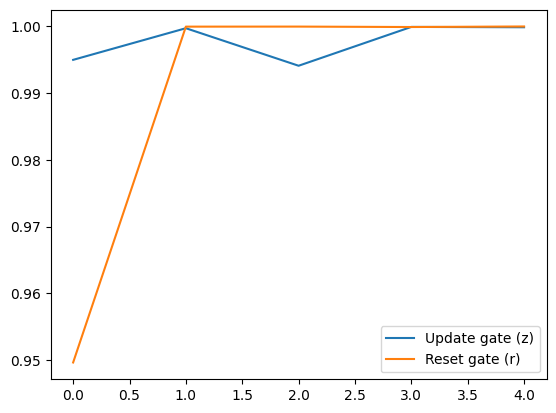

In [5]:
plt.plot(z_list, label="Update gate (z)")
plt.plot(r_list, label="Reset gate (r)")
plt.legend()
plt.show()

In [7]:
# 4 Build a small Keras model with a single GRU layer to predict the next value in a sequence of daily step counts (you can generate random data). Train it for 10 epochs and report the training time and final loss.<br><br><em><strong>Hint:</strong> Compare the training time to a similar LSTM model if possible.</em>

steps = np.random.randint(5000, 15000, 50)

X, y = [], []
for i in range(len(steps)-3):
    X.append(steps[i:i+3])
    y.append(steps[i+3])

X = np.array(X).reshape(-1, 3, 1)
y = np.array(y)

# GRU Model
model = Sequential([
    GRU(16, input_shape=(3, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X, y, epochs=10, verbose=0)

print("Final Loss:", history.history['loss'][-1])


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Loss: 101401168.0
